In [1]:
from core.hydrodispatchenv import HydroDispatchEnv
import numpy as np
import matplotlib.pyplot as plt

env = HydroDispatchEnv(inflow_m3s=25.0)

# Test reset
obs, info = env.reset(seed=42)
print("=== ENVIRONMENT SKELETON TEST ===")
print(f"Observation Space: {env.observation_space}")
print(f"Action Space:      {env.action_space}")
print(f"\nInitial Observation: {obs}")
print(f"  [0] Reservoir Level (norm): {obs[0]:.3f}")
print(f"  [1] Hour of Day (norm):     {obs[1]:.3f}")
print(f"  [2] Inflow (norm):          {obs[2]:.3f}")
print(f"\nInfo: {info}")

# Test step
action = env.action_space.sample()
print(f"\nRandom Action (discharge m³/s): {action}")
obs2, reward, term, trunc, info2 = env.step(action)
print(f"Next Observation: {obs2}")
print(f"Reward: {reward}")

# Test full episode
obs, info = env.reset(seed=0)
total_steps = 0
while True:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_steps += 1
    if terminated or truncated:
        break

print(f"\nFull episode ran for {total_steps} steps ({total_steps/24:.1f} days)")
print(f"Expected: {env.HOURS_PER_EPISODE} steps ({env.HOURS_PER_EPISODE/24} days)")
assert total_steps == env.HOURS_PER_EPISODE, "Episode length mismatch!"
print("✅ Episode length correct.")

=== ENVIRONMENT SKELETON TEST ===
Observation Space: Box(0.0, 1.0, (4,), float32)
Action Space:      Box(0.0, 50.0, (1,), float32)

Initial Observation: [0.5662027  0.         0.5        0.35166767]
  [0] Reservoir Level (norm): 0.566
  [1] Hour of Day (norm):     0.000
  [2] Inflow (norm):          0.500

Info: {'volume_m3': 3047912.097111927, 'step': 0, 'hour_of_day': 0}

Random Action (discharge m³/s): [27.931221]
Next Observation: [0.56384796 0.04347826 0.5        0.47545198]
Reward: 900.0520629882812

Full episode ran for 168 steps (7.0 days)
Expected: 168 steps (7.0 days)
✅ Episode length correct.


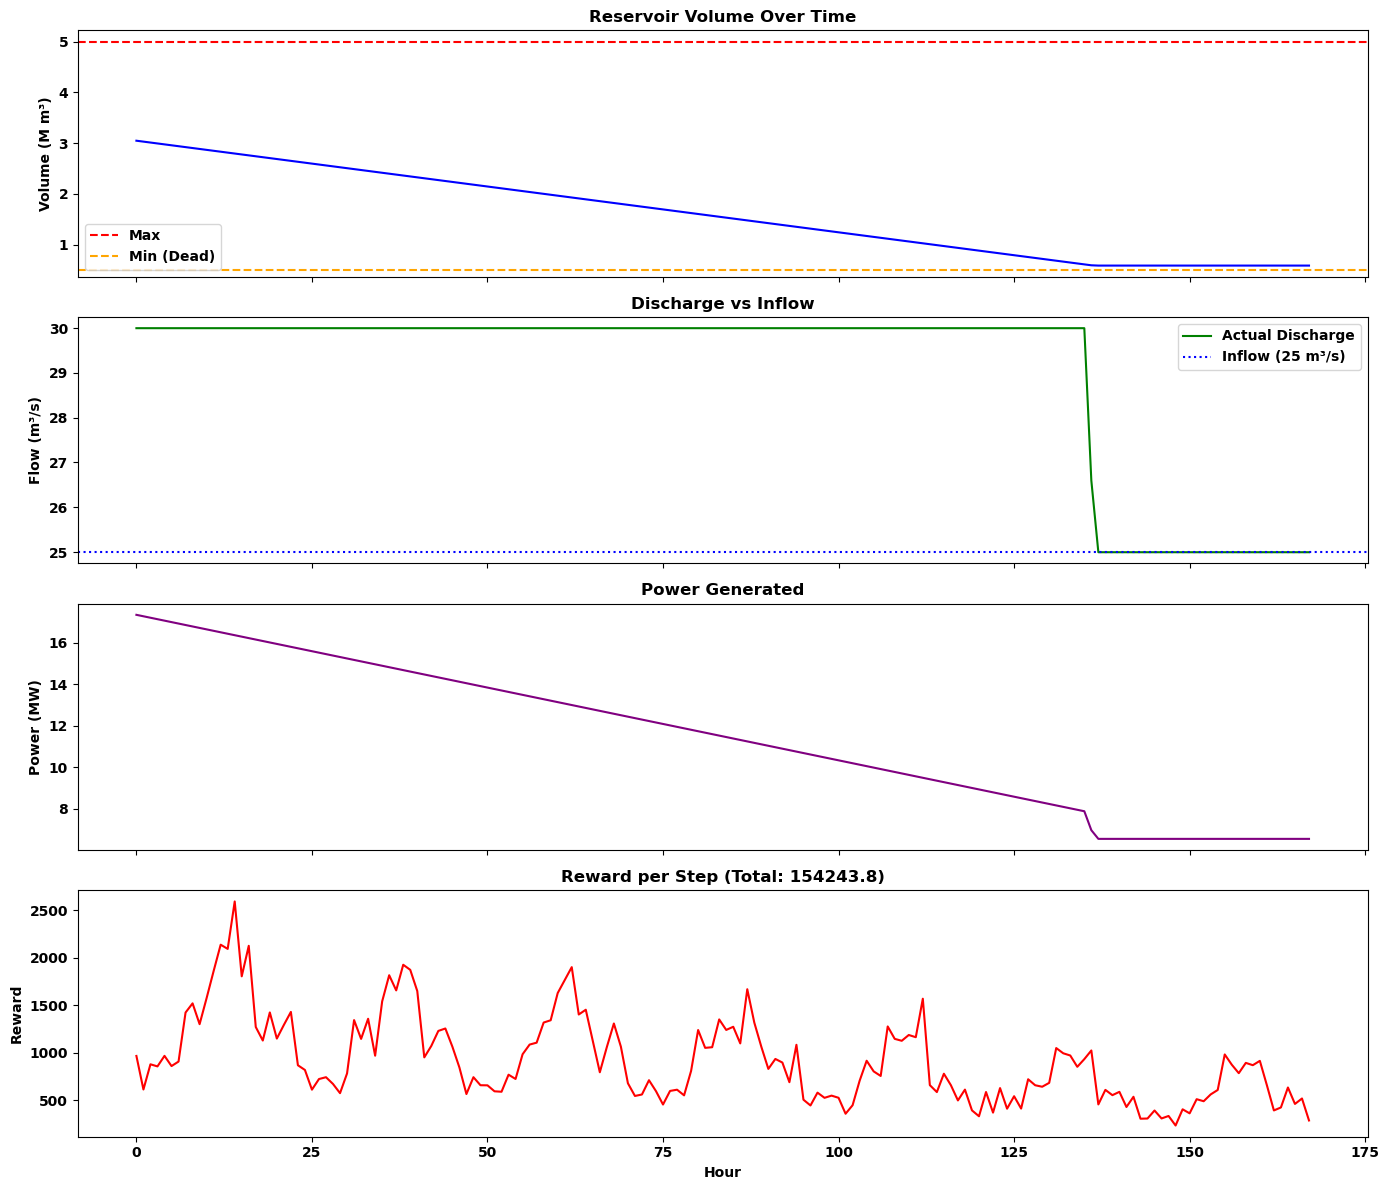


=== MASS BALANCE AUDIT ===
Total Inflow:    15.12 M m³
Total Discharge: 17.57 M m³
Total Spill:     0.00 M m³
ΔStorage:        -2.46 M m³
Balance Error:   0.000002 M m³
  (Should be ≈ 0.0)


In [3]:
env = HydroDispatchEnv(inflow_m3s=25.0)
obs, info = env.reset(seed=42)

# Track variables over a full episode
volumes = [info["volume_m3"]]
powers = []
spills = []
discharges = []
rewards = []
evap_volumes = []

for step in range(env.HOURS_PER_EPISODE):
    # Constant discharge at 30 m³/s (slightly above inflow)
    action = np.array([30.0], dtype=np.float32)
    obs, reward, terminated, truncated, info = env.step(action)

    volumes.append(info["volume_m3"])
    powers.append(info["power_mw"])
    spills.append(info["spill_m3s"])
    discharges.append(info["actual_discharge_m3s"])
    rewards.append(reward)
    evap_volumes.append(info["evap_volume"])

    if terminated:
        break

# === PHYSICS VALIDATION PLOTS ===
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

hours = range(len(volumes) - 1)

axes[0].plot(hours, [v / 1e6 for v in volumes[:-1]], 'b-', linewidth=1.5)
axes[0].axhline(y=env.RESERVOIR_MAX_M3/1e6, color='r', linestyle='--', label='Max')
axes[0].axhline(y=env.RESERVOIR_MIN_M3/1e6, color='orange', linestyle='--', label='Min (Dead)')
axes[0].set_ylabel("Volume (M m³)")
axes[0].set_title("Reservoir Volume Over Time")
axes[0].legend()

axes[1].plot(hours, discharges, 'g-', label='Actual Discharge')
axes[1].axhline(y=25.0, color='blue', linestyle=':', label='Inflow (25 m³/s)')
axes[1].set_ylabel("Flow (m³/s)")
axes[1].set_title("Discharge vs Inflow")
axes[1].legend()

axes[2].plot(hours, powers, 'purple', linewidth=1.5)
axes[2].set_ylabel("Power (MW)")
axes[2].set_title("Power Generated")

axes[3].plot(hours, rewards, 'red', linewidth=1.5)
axes[3].set_ylabel("Reward")
axes[3].set_xlabel("Hour")
axes[3].set_title(f"Reward per Step (Total: {sum(rewards):.1f})")

plt.tight_layout()
plt.show()

# === MASS BALANCE CHECK ===
total_inflow = env.inflow_m3s * env.DT_SECONDS * env.HOURS_PER_EPISODE
total_discharge = sum(d * env.DT_SECONDS for d in discharges)
total_spill = sum(s * env.DT_SECONDS for s in spills)
total_evap = sum(evap_volumes)
delta_storage = volumes[-1] - volumes[0]

print("\n=== MASS BALANCE AUDIT ===")
print(f"Total Inflow:    {total_inflow/1e6:.2f} M m³")
print(f"Total Discharge: {total_discharge/1e6:.2f} M m³")
print(f"Total Spill:     {total_spill/1e6:.2f} M m³")
print(f"ΔStorage:        {delta_storage/1e6:.2f} M m³") # net physical change in the reservoir's water level from Hour 0 to Hour 168.
print(f"Balance Error:   {(total_inflow - total_discharge - total_spill - delta_storage-total_evap)/1e6:.6f} M m³")
print(f"  (Should be ≈ 0.0)")